<a href="https://colab.research.google.com/github/aparna-2001/nifty50-stock-price-forecasting/blob/main/nifty_50_yearly_prediction_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [159]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [113]:


# 1. Merging 7 yearly NSE files (2000-2006) from NIFTY 50

pre2007_files = glob.glob("/content/*.csv")

pre2007_dfs = []
required_cols = ['Open', 'High', 'Low', 'Close']
volume_col_names = ['Volume', 'Shares Traded']

for file in pre2007_files:
    try:
        df_year = pd.read_csv(file)


        df_year.columns = df_year.columns.str.strip().str.title()

        # Finding the date column
        date_col = None
        for col in df_year.columns:
            if 'Date' in col:
                date_col = col
                break

        if date_col:
            df_year['Date'] = pd.to_datetime(df_year[date_col])
            df_year.set_index('Date', inplace=True)


            temp_df = df_year[required_cols].copy()

            # Handling volume column
            found_volume_col = None
            for vol_col in volume_col_names:
                if vol_col.title() in df_year.columns:
                    found_volume_col = vol_col.title()
                    break

            if found_volume_col:
                temp_df['Volume'] = df_year[found_volume_col]
            else:
                temp_df['Volume'] = 0


            temp_df['Adj Close'] = np.nan

            pre2007_dfs.append(temp_df)
        else:
            print(f"Warning: Date column not found in {file}. Skipping this file. Available columns: {df_year.columns.tolist()}")
    except Exception as e:
        print(f"Error processing file {file}: {e}. Skipping.")

# Concatenating all pre-2007 years
if pre2007_dfs:
    pre2007 = pd.concat(pre2007_dfs).sort_index()
    # Removing duplicate dates if any exist after concatenation
    pre2007 = pre2007.loc[~pre2007.index.duplicated(keep='first')]
else:
    print("No valid pre-2007 dataframes were processed.")
    pre2007 = pd.DataFrame(columns=required_cols + ['Volume', 'Adj Close']) # Initialize with expected columns

# 2. existing yfinance data (2007-2026)
yf_data = yf.download('^NSEI', start='2007-01-01', end='2026-03-04', auto_adjust=False)
yf_data.columns = yf_data.columns.droplevel(1)  # Flattening multi-index
yf_data.index.name = 'Date'

# Standardizing yfinance columns to match the target columns if needed
yf_data_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
yf_data = yf_data[yf_data_cols]



if not pre2007.empty:

    pre2007 = pre2007[pre2007.index < yf_data.index.min()]
    full_nifty = pd.concat([pre2007, yf_data]).sort_index().drop_duplicates()
else:
    full_nifty = yf_data.copy()


full_nifty.dropna(subset=['Close'], inplace=True)

# Final check of column names and order
final_columns_order = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
full_nifty = full_nifty[final_columns_order]


print(f"Full dataset: {len(full_nifty)} days ({full_nifty.index[0].year}-{full_nifty.index[-1].year})")
print(full_nifty.head())
print(full_nifty.tail())

# Save complete 25+ year dataset
full_nifty.to_csv('nifty_25years_complete.csv')

/tmp/ipykernel_258/807103263.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_year['Date'] = pd.to_datetime(df_year[date_col])
/tmp/ipykernel_258/807103263.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_year['Date'] = pd.to_datetime(df_year[date_col])
/tmp/ipykernel_258/807103263.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_year['Date'] = pd.to_datetime(df_year[date_col])
/tmp/ipykernel_258/807103263.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent 

Full dataset: 6286 days (1999-2026)
              Open    High     Low   Close    Volume  Adj Close
Date                                                           
1999-01-01  886.75  892.20  882.60  890.80  31356585        NaN
1999-01-04  896.40  905.45  895.75  897.80  32224833        NaN
1999-01-05  901.00  907.20  893.15  907.20  36723940        NaN
1999-01-06  923.30  930.55  915.65  928.25  43232321        NaN
1999-01-07  932.95  961.15  932.95  954.70  65480034        NaN
                    Open          High           Low         Close  Volume  \
Date                                                                         
2026-02-24  25641.800781  25641.800781  25327.599609  25424.650391  439100   
2026-02-25  25512.599609  25652.599609  25428.199219  25482.500000  414200   
2026-02-26  25556.300781  25572.949219  25400.949219  25496.550781  405200   
2026-02-27  25459.849609  25476.400391  25141.300781  25178.650391  438900   
2026-03-02  24659.250000  24989.349609  24603.50

In [114]:
full_nifty_df = pd.read_csv('nifty_25years_complete.csv', index_col='Date', parse_dates=True)
full_nifty_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6286 entries, 1999-01-01 to 2026-03-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       6286 non-null   float64
 1   High       6286 non-null   float64
 2   Low        6286 non-null   float64
 3   Close      6286 non-null   float64
 4   Volume     6286 non-null   int64  
 5   Adj Close  4528 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 343.8 KB


* Dropping adj close for ML model building

In [115]:

full_nifty_df = full_nifty_df[['Open', 'High', 'Low', 'Close', 'Volume']]


yearly = full_nifty_df.groupby(full_nifty_df.index.year).agg({
    'Open': 'first',
    'Close': 'last',
    'High': 'max',
    'Low': 'min',
    'Volume': 'mean'
}).reset_index()

print(yearly.head(10))


   Date         Open        Close         High          Low        Volume
0  1999   886.750000  1480.450000  1522.850000   882.600000  3.934727e+07
1  2000  1482.150000  1263.550000  1818.150000  1108.200000  4.524447e+07
2  2001  1263.500000  1059.050000  1422.950000   849.950000  5.388264e+07
3  2002  1058.850000  1093.500000  1205.950000   920.100000  5.063023e+07
4  2003  1093.600000  1100.150000  1102.100000  1093.600000  3.895817e+07
5  2004  1912.250000  2080.500000  2088.450000  1292.200000  1.066143e+08
6  2005  2080.000000  2836.550000  2857.000000  1894.400000  7.026045e+07
7  2006  2836.800000  3966.400000  4046.850000  2595.650000  8.200846e+07
8  2007  4518.450195  6138.600098  6185.399902  4481.549805  0.000000e+00
9  2008  6136.750000  2959.149902  6357.100098  2252.750000  0.000000e+00


In [116]:
full_nifty_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6286 entries, 1999-01-01 to 2026-03-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6286 non-null   float64
 1   High    6286 non-null   float64
 2   Low     6286 non-null   float64
 3   Close   6286 non-null   float64
 4   Volume  6286 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 294.7 KB


* There are no null values or missing data

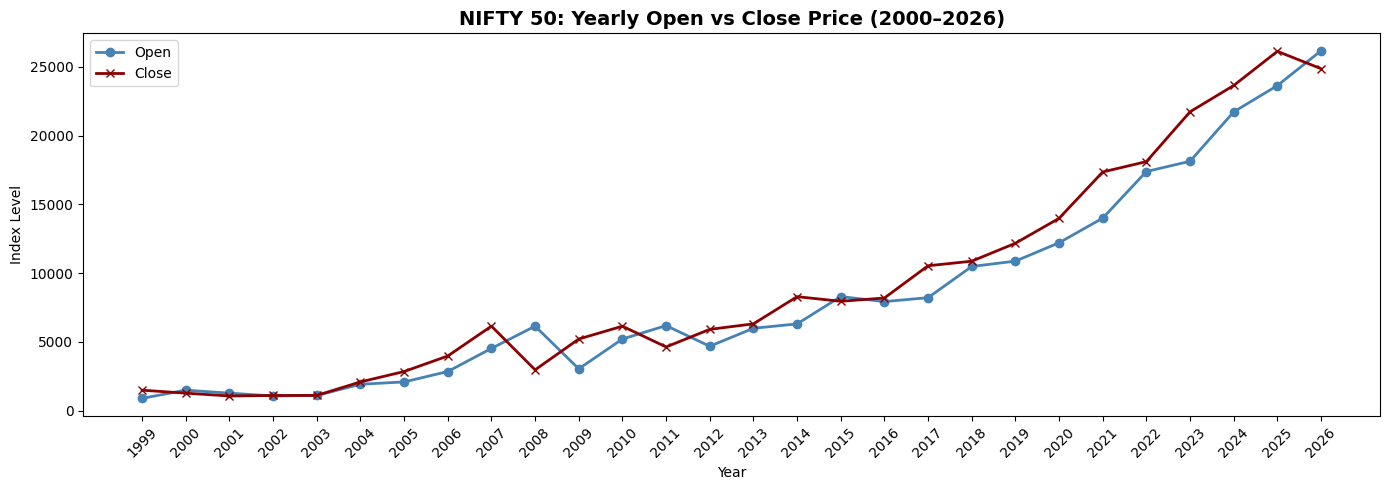

In [117]:
# Yearly aggregation

yearly = full_nifty_df.groupby(full_nifty_df.index.year).agg(
    Year_Open  = ('Open',  'first'),
    Year_Close = ('Close', 'last'),
    Year_High  = ('High',  'max'),
    Year_Low   = ('Low',   'min'),
    Avg_Volume = ('Volume','mean')
).reset_index()


yearly.rename(columns={'Date': 'Year'}, inplace=True) #renaming date to year

# Plot
plt.figure(figsize=(14, 5))
plt.plot(yearly['Year'], yearly['Year_Open'],  label='Open',  marker='o', color='steelblue', linewidth=2)
plt.plot(yearly['Year'], yearly['Year_Close'], label='Close', marker='x', color='darkred',   linewidth=2)

plt.title('NIFTY 50: Yearly Open vs Close Price (2000–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Index Level')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

* Historically the opening and closing prices have evolved higher

*Feature engineering of annual return percentage, candle stick strength and the difference between them*

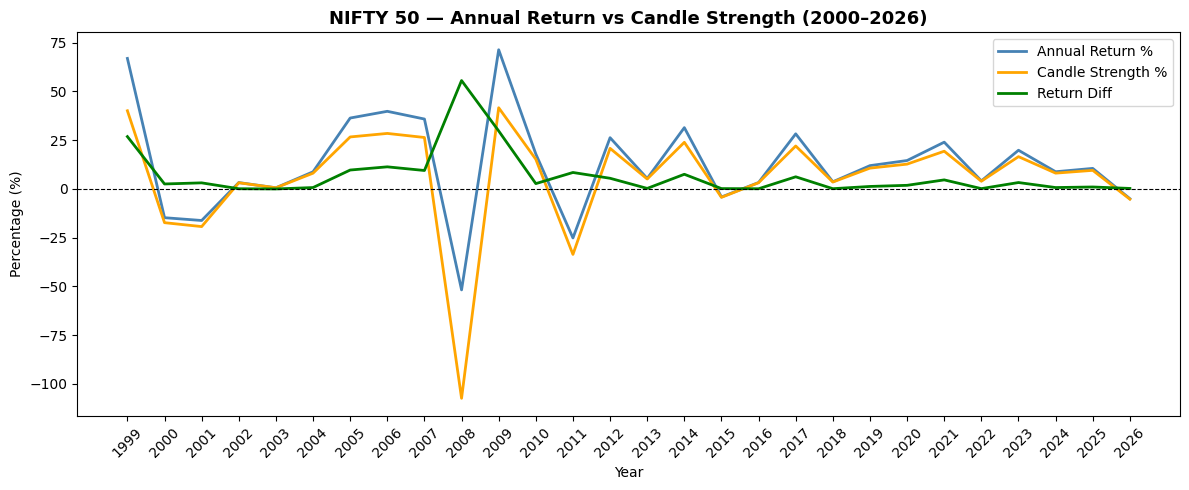

In [118]:
# Feature engineering
yearly['Annual_Return_%']   = (yearly['Year_Close'] - yearly['Year_Open']) / yearly['Year_Open']  * 100
yearly['Candle_Strength_%'] = (yearly['Year_Close'] - yearly['Year_Open']) / yearly['Year_Close'] * 100
yearly['Return_Diff']       = yearly['Annual_Return_%'] - yearly['Candle_Strength_%']

# Plot — fix x-axis by passing yearly['Year']
plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Annual_Return_%'],   label='Annual Return %',    color='steelblue', linewidth=2)
plt.plot(yearly['Year'], yearly['Candle_Strength_%'], label='Candle Strength %',  color='orange',    linewidth=2)
plt.plot(yearly['Year'], yearly['Return_Diff'],       label='Return Diff',        color='green',     linewidth=2)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('NIFTY 50 — Annual Return vs Candle Strength (2000–2026)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [119]:
distorted = yearly[abs(yearly['Candle_Strength_%']) - abs(yearly['Annual_Return_%']) > 10]
print(distorted[['Year', 'Annual_Return_%', 'Candle_Strength_%', 'Return_Diff']])

   Year  Annual_Return_%  Candle_Strength_%  Return_Diff
9  2008       -51.779852        -107.382194    55.602342


* Annual return % and candle stregth % moves in the same direction while the return difference is not

* During markest crashes, the candle strength % falls more than the annual return %

* So candle strength % may be more volatile to market crashes than annual return %

* Divergence is greater for year 2008

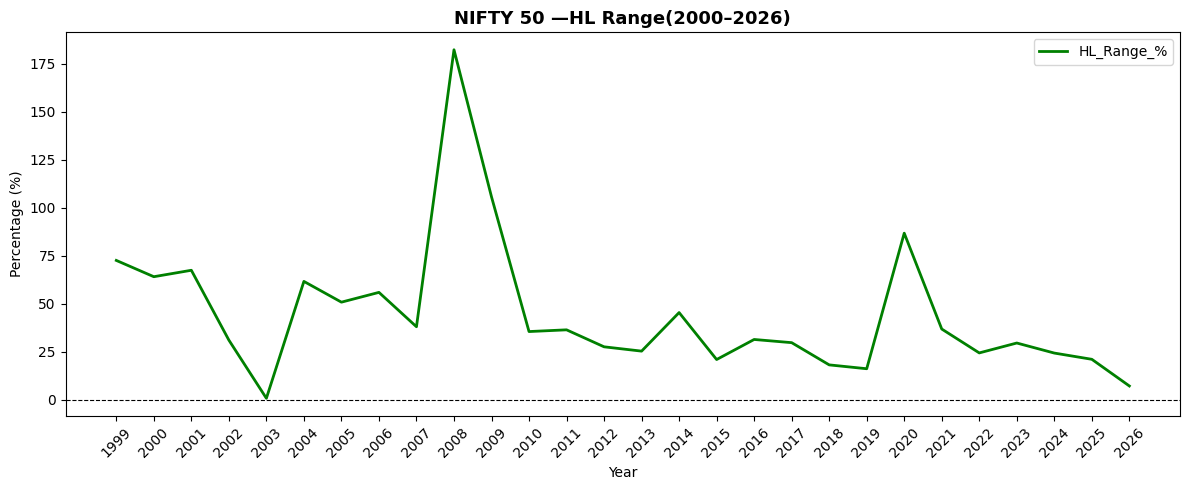

In [120]:
yearly['HL_Range_%'] = (yearly['Year_High'] - yearly['Year_Low']) / yearly['Year_Low'] * 100


plt.figure(figsize=(12, 5))

plt.plot(yearly['Year'], yearly['HL_Range_%'],       label='HL_Range_%',        color='green',     linewidth=2)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('NIFTY 50 —HL Range(2000–2026)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

* Volatility was higher in 2003, 2008, 2020

* 2004 has nearly zero volatility

In [121]:

yearly['Prev_HL_Range_%'] = yearly['HL_Range_%'].shift(1)

In [122]:
yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               28 non-null     int32  
 1   Year_Open          28 non-null     float64
 2   Year_Close         28 non-null     float64
 3   Year_High          28 non-null     float64
 4   Year_Low           28 non-null     float64
 5   Avg_Volume         28 non-null     float64
 6   Annual_Return_%    28 non-null     float64
 7   Candle_Strength_%  28 non-null     float64
 8   Return_Diff        28 non-null     float64
 9   HL_Range_%         28 non-null     float64
 10  Prev_HL_Range_%    27 non-null     float64
dtypes: float64(10), int32(1)
memory usage: 2.4 KB


In [123]:
yearly.dropna(inplace=True)

In [124]:
yearly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 1 to 27
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               27 non-null     int32  
 1   Year_Open          27 non-null     float64
 2   Year_Close         27 non-null     float64
 3   Year_High          27 non-null     float64
 4   Year_Low           27 non-null     float64
 5   Avg_Volume         27 non-null     float64
 6   Annual_Return_%    27 non-null     float64
 7   Candle_Strength_%  27 non-null     float64
 8   Return_Diff        27 non-null     float64
 9   HL_Range_%         27 non-null     float64
 10  Prev_HL_Range_%    27 non-null     float64
dtypes: float64(10), int32(1)
memory usage: 2.4 KB


*feature engineering the recovery rate*

In [125]:
yearly['Recovery_Rate_%'] = (
    (yearly['Year_Close'] - yearly['Year_Low']) /
    (yearly['Year_High'] - yearly['Year_Low'])
) * 100


In [126]:
yearly['Prev_Recovery_Rate_%'] = yearly['Recovery_Rate_%'].shift(1)

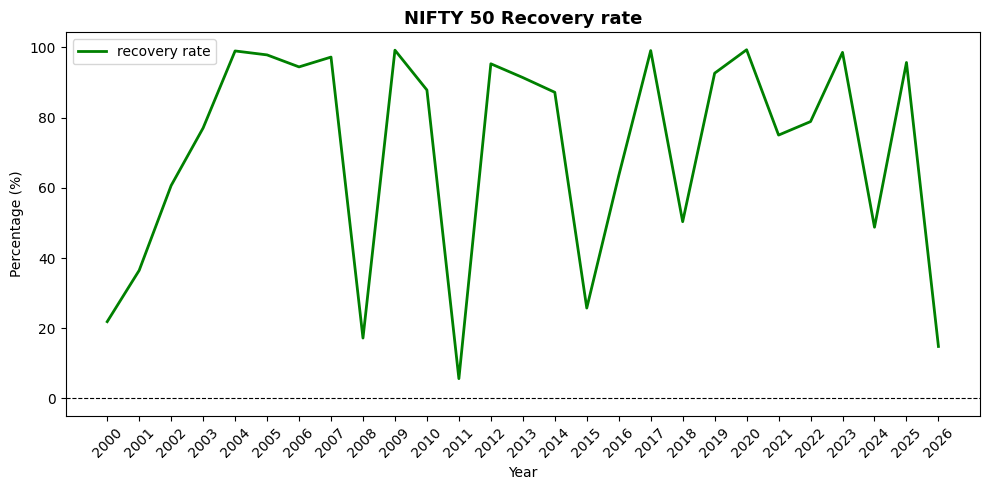

In [127]:

plt.figure(figsize=(10,5))
plt.plot(yearly['Year'], yearly['Recovery_Rate_%'],label='recovery rate',color='green', linewidth=2)


plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('NIFTY 50 Recovery rate', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

*feature engineering for body ratio*

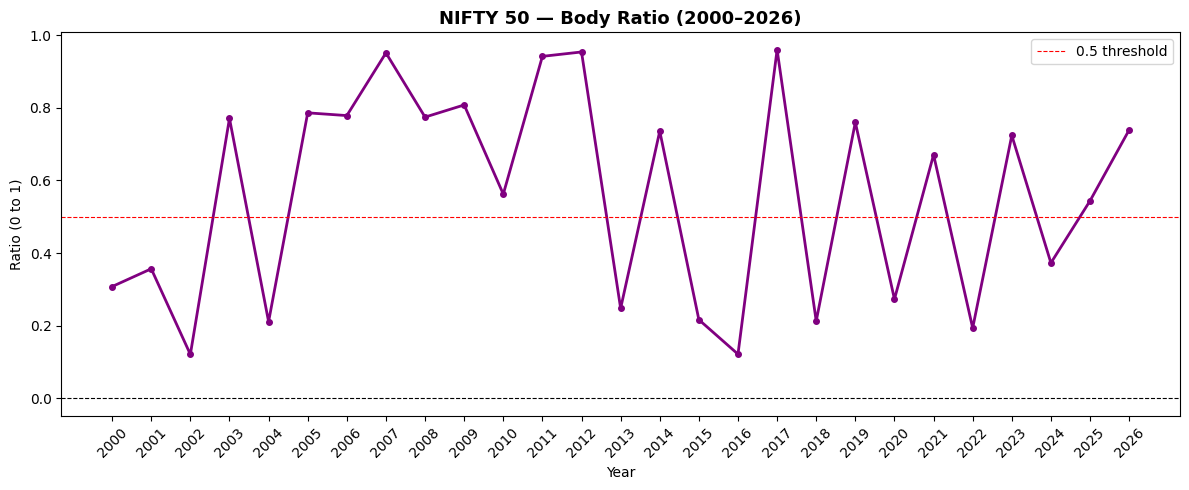

In [128]:
yearly['Body_Ratio'] = (
    abs(yearly['Year_Close'] - yearly['Year_Open']) /
    (yearly['Year_High'] - yearly['Year_Low'])
)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Body_Ratio'],
         color='purple', linewidth=2, marker='o', markersize=4)
plt.axhline(0.5, color='red', linewidth=0.8, linestyle='--', label='0.5 threshold')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.title('NIFTY 50 — Body Ratio (2000–2026)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Ratio (0 to 1)')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

*Feature engineering for upper and lower shadow*

In [129]:
# Upper Shadow — selling pressure at the top

yearly['Upper_Shadow_%'] = (
    (yearly['Year_High'] - yearly[['Year_Open','Year_Close']].max(axis=1)) /
    yearly['Year_High']
) * 100




In [130]:


# Lower Shadow — buying pressure at the bottom
yearly['Lower_Shadow_%'] = (
    (yearly[['Year_Open','Year_Close']].min(axis=1) - yearly['Year_Low']) /
    yearly['Year_Low']
) * 100



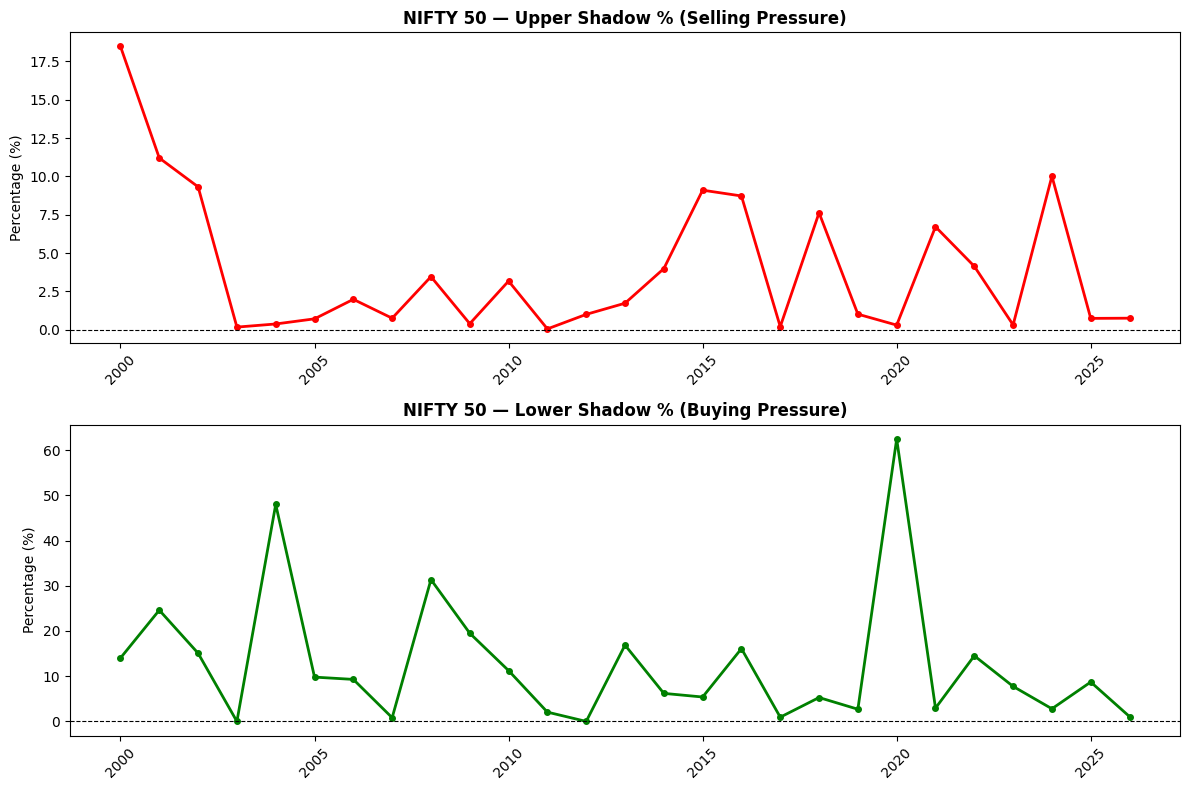

In [131]:
# Plot both
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(yearly['Year'], yearly['Upper_Shadow_%'], color='red', linewidth=2, marker='o', markersize=4)
axes[0].set_title('NIFTY 50 — Upper Shadow % (Selling Pressure)', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(yearly['Year'], yearly['Lower_Shadow_%'], color='green', linewidth=2, marker='o', markersize=4)
axes[1].set_title('NIFTY 50 — Lower Shadow % (Buying Pressure)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

*feature engineering for volume change*

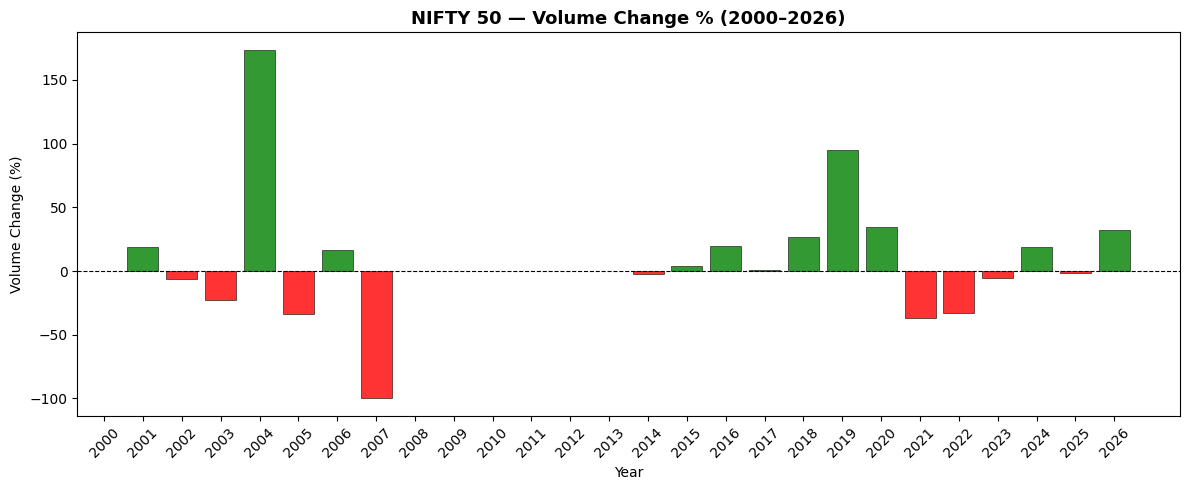

In [132]:
# Volume Change % — year over year change in average volume

yearly['Volume_Change_%'] = yearly['Avg_Volume'].pct_change() * 100


plt.figure(figsize=(12, 5))
plt.bar(yearly['Year'], yearly['Volume_Change_%'],
        color=['green' if x > 0 else 'red' for x in yearly['Volume_Change_%']],
        alpha=0.8, edgecolor='black', linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('NIFTY 50 — Volume Change % (2000–2026)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Volume Change (%)')
plt.xticks(yearly['Year'], rotation=45)
plt.tight_layout()
plt.show()


In [133]:

yearly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 1 to 27
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  27 non-null     int32  
 1   Year_Open             27 non-null     float64
 2   Year_Close            27 non-null     float64
 3   Year_High             27 non-null     float64
 4   Year_Low              27 non-null     float64
 5   Avg_Volume            27 non-null     float64
 6   Annual_Return_%       27 non-null     float64
 7   Candle_Strength_%     27 non-null     float64
 8   Return_Diff           27 non-null     float64
 9   HL_Range_%            27 non-null     float64
 10  Prev_HL_Range_%       27 non-null     float64
 11  Recovery_Rate_%       27 non-null     float64
 12  Prev_Recovery_Rate_%  26 non-null     float64
 13  Body_Ratio            27 non-null     float64
 14  Upper_Shadow_%        27 non-null     float64
 15  Lower_Shadow_%        27 non-n

In [134]:
print(yearly[['Year','Avg_Volume','Volume_Change_%']])

    Year    Avg_Volume  Volume_Change_%
1   2000  4.524447e+07              NaN
2   2001  5.388264e+07        19.092212
3   2002  5.063023e+07        -6.036086
4   2003  3.895817e+07       -23.053550
5   2004  1.066143e+08       173.663546
6   2005  7.026045e+07       -34.098475
7   2006  8.200846e+07        16.720649
8   2007  0.000000e+00      -100.000000
9   2008  0.000000e+00              NaN
10  2009  0.000000e+00              NaN
11  2010  0.000000e+00              NaN
12  2011  0.000000e+00              NaN
13  2012  0.000000e+00              NaN
14  2013  1.599992e+05              inf
15  2014  1.568729e+05        -1.953931
16  2015  1.634939e+05         4.220573
17  2016  1.957885e+05        19.752836
18  2017  1.975605e+05         0.905037
19  2018  2.500853e+05        26.586705
20  2019  4.869087e+05        94.697050
21  2020  6.557856e+05        34.683480
22  2021  4.139927e+05       -36.870718
23  2022  2.783480e+05       -32.765009
24  2023  2.634065e+05        -5.367904


* checking the data, we understand that the volume change is missing some values.

* Here too much values are missing and imputation will introduce more noise to data, so we are dropping the average volume and volume change.

In [135]:

yearly['Avg_Volume'] = yearly['Avg_Volume'].replace(0, np.nan)


yearly.drop(columns=['Avg_Volume', 'Volume_Change_%'], inplace=True)

print("Volume feature dropped — unreliable due to missing data and unit mismatch")
print(yearly.columns.tolist())


Volume feature dropped — unreliable due to missing data and unit mismatch
['Year', 'Year_Open', 'Year_Close', 'Year_High', 'Year_Low', 'Annual_Return_%', 'Candle_Strength_%', 'Return_Diff', 'HL_Range_%', 'Prev_HL_Range_%', 'Recovery_Rate_%', 'Prev_Recovery_Rate_%', 'Body_Ratio', 'Upper_Shadow_%', 'Lower_Shadow_%']


In [136]:
yearly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 1 to 27
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  27 non-null     int32  
 1   Year_Open             27 non-null     float64
 2   Year_Close            27 non-null     float64
 3   Year_High             27 non-null     float64
 4   Year_Low              27 non-null     float64
 5   Annual_Return_%       27 non-null     float64
 6   Candle_Strength_%     27 non-null     float64
 7   Return_Diff           27 non-null     float64
 8   HL_Range_%            27 non-null     float64
 9   Prev_HL_Range_%       27 non-null     float64
 10  Recovery_Rate_%       27 non-null     float64
 11  Prev_Recovery_Rate_%  26 non-null     float64
 12  Body_Ratio            27 non-null     float64
 13  Upper_Shadow_%        27 non-null     float64
 14  Lower_Shadow_%        27 non-null     float64
dtypes: float64(14), int32(1)
memor

In [137]:

yearly.dropna(inplace=True)

# Target Variable
yearly['Target'] = (yearly['Year_Close'].shift(-1) > yearly['Year_Open'].shift(-1)).astype(int)


yearly = yearly[:-1]

# Final feature table
print(yearly[['Year', 'Annual_Return_%', 'Candle_Strength_%', 'Return_Diff',
              'HL_Range_%', 'Prev_HL_Range_%', 'Recovery_Rate_%',
              'Prev_Recovery_Rate_%', 'Body_Ratio',
              'Upper_Shadow_%', 'Lower_Shadow_%', 'Target']].to_string(index=False))

print(f"\nTotal samples : {len(yearly)}")
print(f"Bullish years : {yearly['Target'].sum()}")
print(f"Bearish years : {(yearly['Target']==0).sum()}")

 Year  Annual_Return_%  Candle_Strength_%  Return_Diff  HL_Range_%  Prev_HL_Range_%  Recovery_Rate_%  Prev_Recovery_Rate_%  Body_Ratio  Upper_Shadow_%  Lower_Shadow_%  Target
 2001       -16.181243         -19.305038     3.123795   67.415730        64.063346        36.492147             21.881823    0.356806       11.205594       24.601447       1
 2002         3.272418           3.168724     0.103694   31.067275        67.415730        60.661186             36.492147    0.121217        9.324599       15.079883       1
 2003         0.598939           0.595373     0.003566    0.777249        31.067275        77.058824             60.661186    0.770588        0.176935        0.000000       1
 2004         8.798536           8.086998     0.711537   61.619718         0.777249        99.001570             77.058824    0.211303        0.380665       47.984058       1
 2005        36.372596          26.671485     9.701111   50.812922        61.619718        97.875545             99.001570   

**Model_1 (with all features)**

In [144]:

all_features = [
    'Annual_Return_%',
    'Candle_Strength_%',
    'Return_Diff',
    'HL_Range_%',
    'Prev_HL_Range_%',
    'Recovery_Rate_%',
    'Prev_Recovery_Rate_%',
    'Body_Ratio', 'Upper_Shadow_%',
    'Lower_Shadow_%'
]


split = int(len(yearly) * 0.8)

x = yearly[all_features]
y = yearly['Target']

x_train = yearly[all_features].iloc[:split]
x_test  = yearly[all_features].iloc[split:]
y_train = yearly['Target'].iloc[:split]
y_test  = yearly['Target'].iloc[split:]

print(f"Train: {len(y_train)} years ({yearly['Year'].iloc[0]}–{yearly['Year'].iloc[split-1]})")
print(f"Test : {len(y_test)}  years ({yearly['Year'].iloc[split]}–{yearly['Year'].iloc[-1]})")
print(f"\nTrain — Bullish: {y_train.sum()}, Bearish: {(y_train==0).sum()}")
print(f"Test  — Bullish: {y_test.sum()},  Bearish: {(y_test==0).sum()}")

Train: 20 years (2001–2020)
Test : 5  years (2021–2025)

Train — Bullish: 17, Bearish: 3
Test  — Bullish: 4,  Bearish: 1


In [145]:

# Training

m1 = XGBClassifier(n_estimators=100, max_depth=3, eval_metric='logloss', random_state=42)
m1.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [146]:
# Evaluation

preds = m1.predict(x_test)
preds

array([0, 1, 1, 1, 1])

In [147]:
print("M1 — All Features")
print(f"Accuracy : {accuracy_score(y_test, preds)*100:.1f}%")
print(f"F1 Score : {f1_score(y_test, preds, zero_division=0):.3f}")
print(f"Predicted: {preds.tolist()}")
print(f"Actual   : {y_test.tolist()}")

M1 — All Features
Accuracy : 60.0%
F1 Score : 0.750
Predicted: [0, 1, 1, 1, 1]
Actual   : [1, 1, 1, 1, 0]


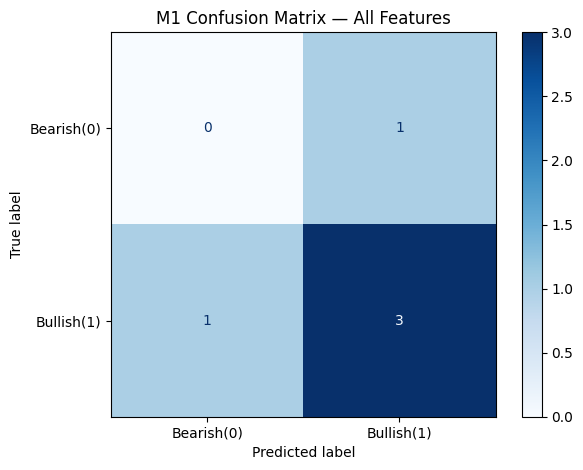

In [149]:

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bearish(0)', 'Bullish(1)'])
disp.plot(cmap='Blues')
plt.title('M1 Confusion Matrix — All Features')
plt.tight_layout()
plt.show()


* 1 bearish year predicted as bullish

* 1 bullish year predicted as bearish

**Model_2 (without annual return)**

M2 — Without Annual_Return_%
Accuracy : 60.0%
F1 Score : 0.750
Predicted: [0, 1, 1, 1, 1]
Actual   : [1, 1, 1, 1, 0]


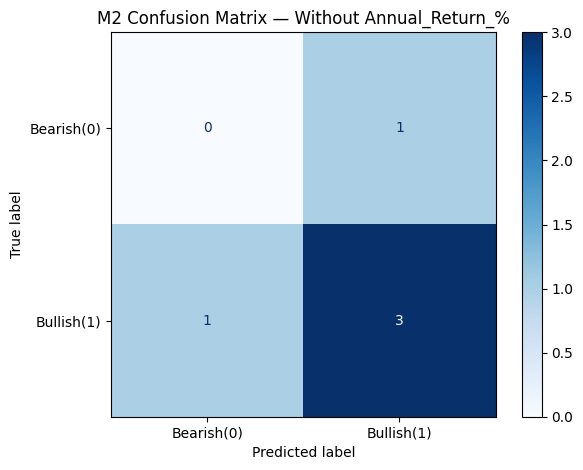

In [151]:
# M2 — Remove Annual_Return_%
features_m2 = [f for f in all_features if f != 'Annual_Return_%']

x_train_2 = yearly[features_m2].iloc[:split]
x_test_2 = yearly[features_m2].iloc[split:]

m2 = XGBClassifier(n_estimators=100, max_depth=3, eval_metric='logloss', random_state=42)
m2.fit(x_train_2,
       y_train)

preds_m2 = m2.predict(x_test_2)

print("M2 — Without Annual_Return_%")
print(f"Accuracy : {accuracy_score(y_test, preds_m2)*100:.1f}%")
print(f"F1 Score : {f1_score(y_test, preds_m2, zero_division=0):.3f}")
print(f"Predicted: {preds_m2.tolist()}")
print(f"Actual   : {y_test.tolist()}")

# Confusion matrix
cm2 = confusion_matrix(y_test, preds_m2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Bearish(0)','Bullish(1)'])
disp2.plot(cmap='Blues')
plt.title('M2 Confusion Matrix — Without Annual_Return_%')
plt.tight_layout()
plt.show()

*same result as model 1

**Model_3 (without candle strength)**

M3 — Without Candle_Strength_%
Accuracy : 60.0%
F1 Score : 0.750
Predicted: [0, 1, 1, 1, 1]
Actual   : [1, 1, 1, 1, 0]


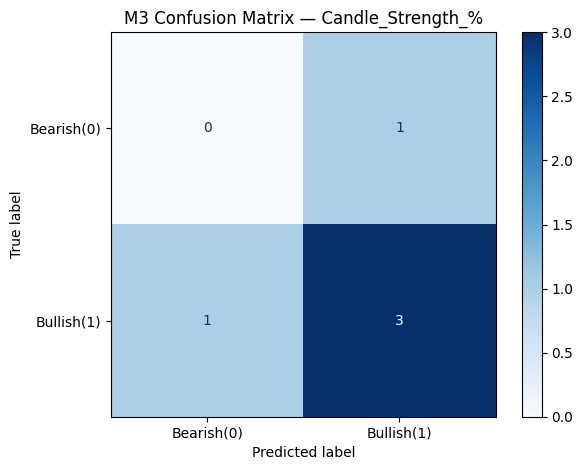

In [156]:
# M3 — Remove Candle_Strength_%
features_m3 = [f for f in all_features if f != 'Candle_Strength_%']

x_train_3 = yearly[features_m3].iloc[:split]
x_test_3= yearly[features_m3].iloc[split:]

m3 = XGBClassifier(n_estimators=100, max_depth=3, eval_metric='logloss', random_state=42)
m3.fit(x_train_3,
       y_train)

preds_m3 = m3.predict(x_test_3)

print("M3 — Without Candle_Strength_%")
print(f"Accuracy : {accuracy_score(y_test, preds_m3)*100:.1f}%")
print(f"F1 Score : {f1_score(y_test, preds_m3, zero_division=0):.3f}")
print(f"Predicted: {preds_m3.tolist()}")
print(f"Actual   : {y_test.tolist()}")

# Confusion matrix
cm3 = confusion_matrix(y_test, preds_m3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['Bearish(0)','Bullish(1)'])
disp3.plot(cmap='Blues')
plt.title('M3 Confusion Matrix — Candle_Strength_%')
plt.tight_layout()
plt.show()

* same as above models

**Model_4 (without return difference)**

M4 — Without Return_Diff
Accuracy : 60.0%
F1 Score : 0.750
Predicted: [0, 1, 1, 1, 1]
Actual   : [1, 1, 1, 1, 0]


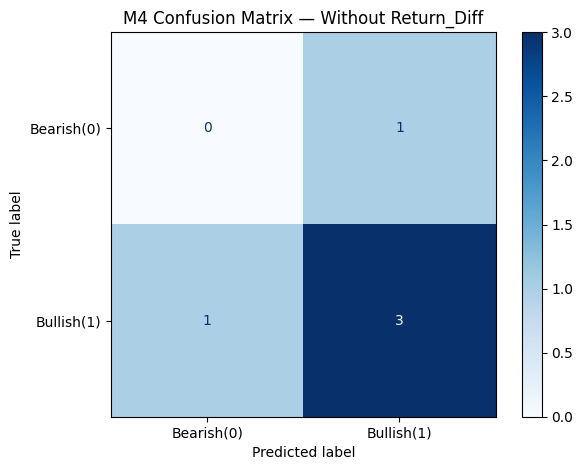

In [157]:
# M4 — Removing Return_Diff
features_m4 = [f for f in all_features if f != 'Return_Diff']

x_train_4 = yearly[features_m4].iloc[:split]
x_test_4  = yearly[features_m4].iloc[split:]

m4 = XGBClassifier(n_estimators=100, max_depth=3, eval_metric='logloss', random_state=42)
m4.fit(x_train_4, y_train)

preds_m4 = m4.predict(x_test_4)

print("M4 — Without Return_Diff")
print(f"Accuracy : {accuracy_score(y_test, preds_m4)*100:.1f}%")
print(f"F1 Score : {f1_score(y_test, preds_m4, zero_division=0):.3f}")
print(f"Predicted: {preds_m4.tolist()}")
print(f"Actual   : {y_test.tolist()}")

cm4 = confusion_matrix(y_test, preds_m4)
ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=['Bearish(0)','Bullish(1)']).plot(cmap='Blues')
plt.title('M4 Confusion Matrix — Without Return_Diff')
plt.tight_layout()
plt.show()

**Model_5 (Only structural features)**

M5 — Structural Features Only
Accuracy : 60.0%
F1 Score : 0.750
Predicted: [0, 1, 1, 1, 1]
Actual   : [1, 1, 1, 1, 0]


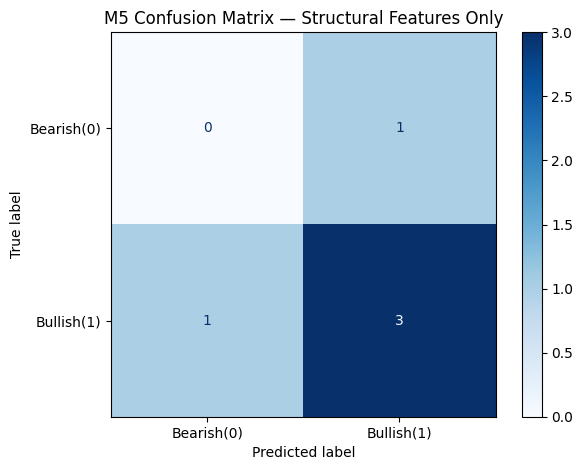

In [158]:
# M5 — Structural Features Only
features_m5 = ['HL_Range_%', 'Prev_HL_Range_%', 'Recovery_Rate_%',
                'Prev_Recovery_Rate_%', 'Body_Ratio', 'Upper_Shadow_%', 'Lower_Shadow_%']

x_train_5 = yearly[features_m5].iloc[:split]
x_test_5  = yearly[features_m5].iloc[split:]

m5 = XGBClassifier(n_estimators=100, max_depth=3, eval_metric='logloss', random_state=42)
m5.fit(x_train_5, y_train)

preds_m5 = m5.predict(x_test_5)

print("M5 — Structural Features Only")
print(f"Accuracy : {accuracy_score(y_test, preds_m5)*100:.1f}%")
print(f"F1 Score : {f1_score(y_test, preds_m5, zero_division=0):.3f}")
print(f"Predicted: {preds_m5.tolist()}")
print(f"Actual   : {y_test.tolist()}")

cm5 = confusion_matrix(y_test, preds_m5)
ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=['Bearish(0)','Bullish(1)']).plot(cmap='Blues')
plt.title('M5 Confusion Matrix — Structural Features Only')
plt.tight_layout()
plt.show()

* All models behave in the same way

* Since we are dealing with yearly data of nifty, which only comprises of 27 years, this result may be because of **data scarcity**

* This result can also be due to XGbooster overpowering

#Trying different algorithms

           * Logistic regression
           * Random forest

**Logistic Regression**

In [161]:

# Using M5 structural features
x_train_5 = yearly[features_m5].iloc[:split]
x_test_5  = yearly[features_m5].iloc[split:]

# Logistic Regression
logistic_regression_model = LogisticRegression(random_state=42)
logistic_regression_model.fit(x_train_5, y_train)
preds_lr = logistic_regression_model.predict(x_test_5)




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [165]:
# Random Forest
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(x_train_5, y_train)
preds_rf = random_forest.predict(x_test_5)




In [163]:
# Results
for name, preds in [('Logistic Regression', preds_lr), ('Random Forest', preds_rf)]:
    print(f"{name}")
    print(f"Accuracy : {accuracy_score(y_test, preds)*100:.1f}%")
    print(f"F1 Score : {f1_score(y_test, preds, zero_division=0):.3f}")
    print(f"Predicted: {preds.tolist()}")
    print(f"Actual   : {y_test.tolist()}")
    print()

Logistic Regression
Accuracy : 40.0%
F1 Score : 0.571
Predicted: [0, 1, 1, 0, 1]
Actual   : [1, 1, 1, 1, 0]

Random Forest
Accuracy : 60.0%
F1 Score : 0.750
Predicted: [0, 1, 1, 1, 1]
Actual   : [1, 1, 1, 1, 0]



* Logistic regression has lower accuracy than Random forest and XGboost

* This outcome might suggest the data scarcity

In [168]:
tscv = TimeSeriesSplit(n_splits=5)

for algo_name, algo in [
    ('XGBoost', XGBClassifier(n_estimators=100, max_depth=3, eval_metric='logloss', random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter= 1000))]:

    print(f"\n{algo_name} — Walk Forward Validation")
    accuracies = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(yearly[features_m5])):
        y_tr = yearly['Target'].iloc[train_idx]

        # Skip fold if training data has only one class
        if len(y_tr.unique()) < 2:
            print(f"  Fold {fold+1} | Skipped — only one class in training data")
            continue

        X_tr = yearly[features_m5].iloc[train_idx]
        X_te = yearly[features_m5].iloc[test_idx]
        y_te = yearly['Target'].iloc[test_idx]

        algo.fit(X_tr, y_tr)
        preds = algo.predict(X_te)
        acc   = accuracy_score(y_te, preds) * 100
        accuracies.append(acc)

        print(f"  Fold {fold+1} | Train: {yearly['Year'].iloc[train_idx[0]]}–{yearly['Year'].iloc[train_idx[-1]]} | Test: {yearly['Year'].iloc[test_idx].tolist()} | Acc: {acc:.1f}%")

    if accuracies:
        print(f"  Avg Accuracy: {sum(accuracies)/len(accuracies):.1f}%")


XGBoost — Walk Forward Validation
  Fold 1 | Skipped — only one class in training data
  Fold 2 | Train: 2001–2009 | Test: [2010, 2011, 2012, 2013] | Acc: 75.0%
  Fold 3 | Train: 2001–2013 | Test: [2014, 2015, 2016, 2017] | Acc: 75.0%
  Fold 4 | Train: 2001–2017 | Test: [2018, 2019, 2020, 2021] | Acc: 50.0%
  Fold 5 | Train: 2001–2021 | Test: [2022, 2023, 2024, 2025] | Acc: 75.0%
  Avg Accuracy: 68.8%

Random Forest — Walk Forward Validation
  Fold 1 | Skipped — only one class in training data
  Fold 2 | Train: 2001–2009 | Test: [2010, 2011, 2012, 2013] | Acc: 75.0%
  Fold 3 | Train: 2001–2013 | Test: [2014, 2015, 2016, 2017] | Acc: 75.0%
  Fold 4 | Train: 2001–2017 | Test: [2018, 2019, 2020, 2021] | Acc: 75.0%
  Fold 5 | Train: 2001–2021 | Test: [2022, 2023, 2024, 2025] | Acc: 75.0%
  Avg Accuracy: 75.0%

Logistic Regression — Walk Forward Validation
  Fold 1 | Skipped — only one class in training data
  Fold 2 | Train: 2001–2009 | Test: [2010, 2011, 2012, 2013] | Acc: 100.0%
  Fold 

| Algorithm            | Fold2 | Fold3 | Fold4 | Fold5 | Avg   |
|----------------------|-------|-------|-------|-------|-------|
| XGBoost              | 75.0% | 75.0% | 50.0% | 75.0% | 68.8% |
| Random Forest        | 75.0% | 75.0% | 75.0% | 75.0% | 75.0% |
| Logistic Regression  | 100%  | 75.0% | 50.0% | 75.0% | 75.0% |

In [170]:

print("""
| Algorithm           | Fold2  | Fold3  | Fold4  | Fold5  | Avg   |
|---------------------|--------|--------|--------|--------|-------|
| XGBoost             | 75.0%  | 75.0%  | 50.0%  | 75.0%  | 68.8% |
| Random Forest       | 75.0%  | 75.0%  | 75.0%  | 75.0%  | 75.0% |
| Logistic Regression | 100.0% | 75.0%  | 50.0%  | 75.0%  | 75.0% |
""")



| Algorithm           | Fold2  | Fold3  | Fold4  | Fold5  | Avg   |
|---------------------|--------|--------|--------|--------|-------|
| XGBoost             | 75.0%  | 75.0%  | 50.0%  | 75.0%  | 68.8% |
| Random Forest       | 75.0%  | 75.0%  | 75.0%  | 75.0%  | 75.0% |
| Logistic Regression | 100.0% | 75.0%  | 50.0%  | 75.0%  | 75.0% |



**Random Forest** is very consistent in all folds

* Logistic regression shows heavy variations

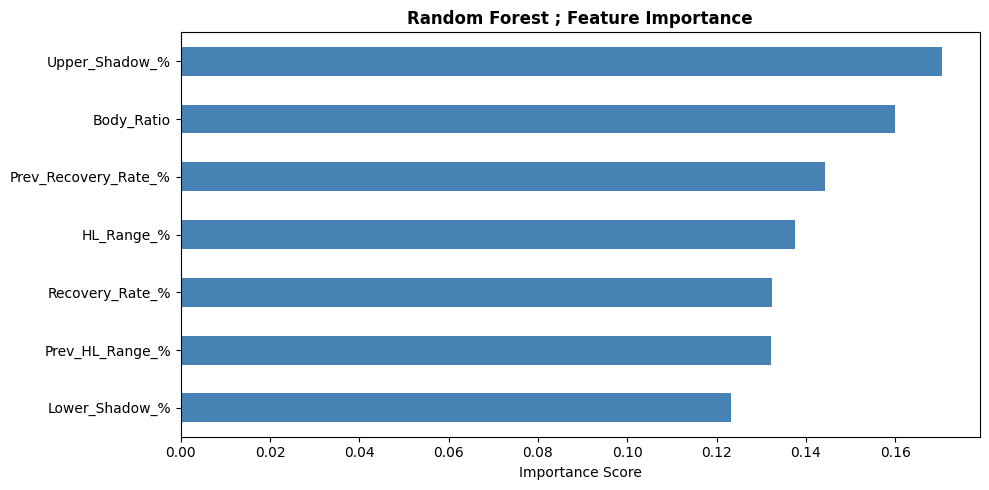

In [172]:
# Training Random Forest on full data

rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(yearly[features_m5], yearly['Target'])

# Feature Importance Plot

importance = pd.Series(rf_final.feature_importances_, index=features_m5).sort_values()

plt.figure(figsize=(10, 5))
importance.plot(kind='barh', color='steelblue')
plt.title('Random Forest ; Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Prediction**

*2026*

In [173]:
# Get 2026 data (current year features)
current_2026 = yearly[features_m5].iloc[-1:]
print("2026 Features:")
print(current_2026.to_string())

# Predict
pred_2026 = rf_final.predict(current_2026)
prob_2026 = rf_final.predict_proba(current_2026)

print(f"\n2026 Prediction : {'BULLISH 📈' if pred_2026[0]==1 else 'BEARISH 📉'}")
print(f"Bullish Probability: {prob_2026[0][1]*100:.1f}%")
print(f"Bearish Probability: {prob_2026[0][0]*100:.1f}%")

2026 Features:
    HL_Range_%  Prev_HL_Range_%  Recovery_Rate_%  Prev_Recovery_Rate_%  Body_Ratio  Upper_Shadow_%  Lower_Shadow_%
26    21.07351         24.31803        95.718142             48.784595    0.543838        0.745281        8.710589

2026 Prediction : BEARISH 📉
Bullish Probability: 21.0%
Bearish Probability: 79.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: U

2026 Bullish Probability:
  Mean  : 21.0%
  Lower (5th percentile) : 0.0%
  Upper (95th percentile): 100.0%


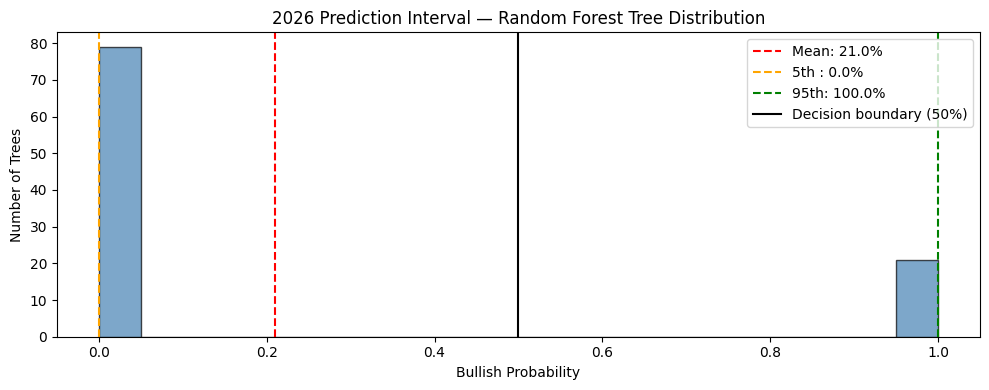

In [174]:
# Prediction Interval using Random Forest individual tree predictions
tree_preds = [tree.predict_proba(current_2026)[0][1] for tree in rf_final.estimators_]

import numpy as np
mean_prob  = np.mean(tree_preds)
lower      = np.percentile(tree_preds, 5)
upper      = np.percentile(tree_preds, 95)

print(f"2026 Bullish Probability:")
print(f"  Mean  : {mean_prob*100:.1f}%")
print(f"  Lower (5th percentile) : {lower*100:.1f}%")
print(f"  Upper (95th percentile): {upper*100:.1f}%")

# Plot distribution
plt.figure(figsize=(10,4))
plt.hist(tree_preds, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_prob, color='red',    linestyle='--', label=f'Mean: {mean_prob*100:.1f}%')
plt.axvline(lower,     color='orange', linestyle='--', label=f'5th : {lower*100:.1f}%')
plt.axvline(upper,     color='green',  linestyle='--', label=f'95th: {upper*100:.1f}%')
plt.axvline(0.5,       color='black',  linestyle='-',  label='Decision boundary (50%)')
plt.title('2026 Prediction Interval — Random Forest Tree Distribution')
plt.xlabel('Bullish Probability')
plt.ylabel('Number of Trees')
plt.legend()
plt.tight_layout()
plt.show()

## PROJECT CONCLUSIONS — NIFTY 50 YEARLY PREDICTION

### DATA
- 25 years of NIFTY 50 data (2001–2025)
- Volume data dropped — missing 2007–2012, unit mismatch

### FEATURES
- Return-based features (Annual Return, Candle Strength, Return Diff) had zero impact
- Structural features (Upper Shadow, Body Ratio, Recovery Rate) drove all predictions
- Upper Shadow % was the most important feature
- Lower Shadow was the least important
- Feature dominance (using RF) identified, no one or few features dominates the prediction

### MODELS
- All 5 ablation models gave identical results (60% accuracy) (using XGBoost)
- Random Forest = best (75% consistent)
- Logistic regression gave least accuracy among all models when analysed without fold
- XGBoost = 68.8%, Logistic Regression = 75% but inconsistent

### 2026 PREDICTION
- BEARISH (79% confidence)
- Reason: 2025 closed near yearly high (Recovery Rate 95.7%) → mean reversion expected

### LIMITATIONS
- Only 25 data points — too small for robust ML
- Only 4 bearish years — severe class imbalance
- Prediction interval unreliable (0%-100%) due to data scarcity
- No macroeconomic features (GDP, inflation, FII flows)
